# U18 — Clustering (Part 1): Lab

### Real-world brief: discovering machine operating regimes

A CNC machine logs telemetry every few seconds — spindle speed, feed rate, cut depth, power, vibration, coolant flow, tool temperature — but **nobody labelled what the machine was doing**. The process engineers suspect the machine runs in a few distinct **operating regimes** (idle, roughing, finishing, heavy cut) and want to recover them automatically to build dashboards and maintenance rules. That's a **k-means clustering** job: scale the data, choose k, validate, and profile the clusters.

**Resource provided:** `machine_operating_data.csv` (one row per reading, **no label column** — the regime is what you'll discover). Keep it beside this notebook (upload it in Colab).

_Phase E — Unsupervised Learning (Clustering, Part 1)._

#objectives

Scale features correctly before any distance-based clustering

Run k-means and read its inertia and labels

Choose k with the elbow and silhouette methods

Validate clusters with silhouette and Davies-Bouldin scores

Profile and name the discovered regimes; preview DBSCAN

#how to use this lab

Worked demos teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace `# YOUR CODE HERE`. Run top to bottom with Shift+Enter.

In [16]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_regimes(csv_path="machine_operating_data.csv", seed=180, verbose=False):
    """CNC machine operating telemetry — UNLABELLED readings to be clustered into
    operating regimes (e.g. idle / roughing / finishing / heavy-cut). Built with a few
    genuine latent regimes so k-means has real structure to recover, plus features on
    very different scales (scaling lesson) for the U18 clustering lab.

    Features:
      spindle_rpm        spindle speed (rev/min)
      feed_rate_mmpm     feed rate (mm/min)
      cut_depth_mm       depth of cut (mm)
      power_kw           spindle power (kW)
      vibration_mm_s     vibration (mm/s)
      coolant_lpm        coolant flow (L/min)
      tool_temp_c        tool temperature (deg C)
    No label column (the 'regime' is what clustering should discover).
    """
    rng = np.random.default_rng(seed)
    # latent regimes: (rpm, feed, depth, power, vib, coolant, temp), weight
    regimes = [
        ("idle",      (700,   0,    0.0,  1.5,  0.6, 2,   28), 0.20),
        ("roughing",  (1500,  400,  3.5,  18,   5.5, 25,  62), 0.30),
        ("finishing", (3000,  180,  0.6,  9,    2.2, 18,  48), 0.30),
        ("heavy_cut", (1100,  600,  6.0,  26,   8.5, 30,  78), 0.20),
    ]
    N = 1500
    rows = []
    for name, mu, w in regimes:
        n = int(N * w)
        spread = np.array([120, 50, 0.4, 2.0, 0.7, 3, 5])
        block = rng.normal(mu, spread, size=(n, 7))
        rows.append(block)
    X = np.vstack(rows)
    X[:, :] = np.clip(X, 0, None)
    rng.shuffle(X)

    df = pd.DataFrame(X, columns=[
        "spindle_rpm", "feed_rate_mmpm", "cut_depth_mm", "power_kw",
        "vibration_mm_s", "coolant_lpm", "tool_temp_c"])
    df["spindle_rpm"] = df.spindle_rpm.round(0).astype(int)
    df["feed_rate_mmpm"] = df.feed_rate_mmpm.round(0).astype(int)
    for c in ["cut_depth_mm", "power_kw", "vibration_mm_s", "tool_temp_c"]:
        df[c] = df[c].round(2)
    df["coolant_lpm"] = df.coolant_lpm.round(1)
    df.to_csv(csv_path, index=False)
    if verbose:
        print("regimes:", df.shape)
        print("feature ranges (max-min):")
        print((df.max() - df.min()).round(1).to_string())
        print("(built from 4 latent regimes; no label column kept)")
    return df

if not os.path.exists('machine_operating_data.csv'):
    build_regimes(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Generated dataset file.


In [31]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
df = pd.read_csv('machine_operating_data.csv')
print('readings:', df.shape)
print('feature ranges (max-min) — note how different they are:')
print((df.max() - df.min()).round(1).to_string())
df.head(3)

readings: (1500, 7)
feature ranges (max-min) — note how different they are:
spindle_rpm       2924.0
feed_rate_mmpm     781.0
cut_depth_mm         7.1
power_kw            31.4
vibration_mm_s      10.2
coolant_lpm         39.5
tool_temp_c         75.6


,spindle_rpm,feed_rate_mmpm,cut_depth_mm,power_kw,vibration_mm_s,coolant_lpm,tool_temp_c
0,2860,202,0.49,7.78,3.06,20.3,42.31
1,1373,428,3.60,20.04,6.28,29.1,61.35
2,3031,237,0.36,12.23,3.17,14.1,47.21


#1. Scale first — always

In [18]:
# -----------------------------------------------------------
# 🔹 1A. WHY: spindle_rpm spans ~3000, cut_depth spans ~7
# -----------------------------------------------------------
from sklearn.preprocessing import StandardScaler
X = df.values
Xs = StandardScaler().fit_transform(X)
print('raw    feature stds:', np.round(X.std(axis=0), 1))
print('scaled feature stds:', np.round(Xs.std(axis=0), 1))
print('After scaling every feature has std ~1, so each gets an equal vote in the distance.')

raw    feature stds: [896.  208.6   2.2   8.6   2.9  10.   17.4]
scaled feature stds: [1. 1. 1. 1. 1. 1. 1.]
After scaling every feature has std ~1, so each gets an equal vote in the distance.


#### 🧪 EXERCISE 1 — Prove scaling matters
1. Run `KMeans(n_clusters=4, n_init=10, random_state=0)` on the **raw** `X` and on the **scaled** `Xs`.
2. For each, print the cluster sizes (`np.bincount(labels)`).
3. In a comment, note whether the raw clustering is dominated by one feature (lopsided cluster sizes often signal `spindle_rpm` taking over).

In [41]:
from sklearn.cluster import KMeans
# 1-2. k-means on raw vs scaled, print cluster sizes
# Run with multiple inits for stability (n_init=10)
KMeans_raw = KMeans(n_clusters=4, n_init=10, random_state=0).fit(X)
KMeans_scaled = KMeans(n_clusters=4, n_init=10, random_state=0).fit(Xs)
print( np.bincount(KMeans_raw.labels_))
print(np.bincount(KMeans_scaled.labels_))
# 3. is raw dominated by one feature? \
#Yes





[444 450 300 306]
[450 300 450 300]


#2. Run k-means

In [42]:
# -----------------------------------------------------------
# 🔹 2A. FIT k-MEANS (k=4) ON SCALED DATA
# -----------------------------------------------------------
from sklearn.cluster import KMeans
km = KMeans(n_clusters=4, n_init=10, random_state=0).fit(Xs)
print('inertia (within-cluster SSE):', round(km.inertia_, 1))
print('cluster sizes:', np.bincount(km.labels_))
print('n_init=10 runs k-means 10 times from different starts and keeps the lowest-inertia result.')

inertia (within-cluster SSE): 549.9
cluster sizes: [450 300 450 300]
n_init=10 runs k-means 10 times from different starts and keeps the lowest-inertia result.


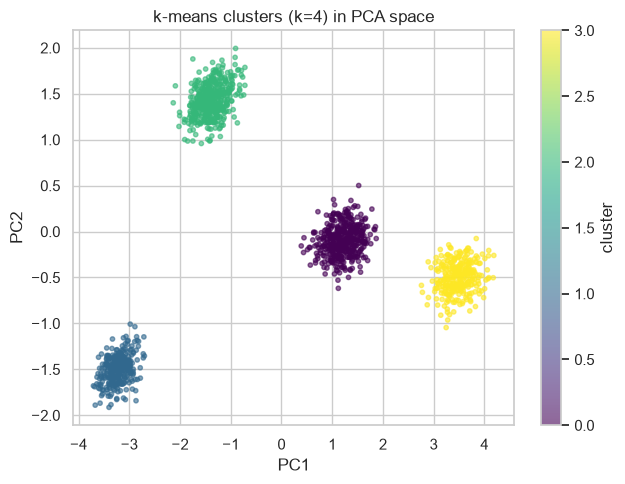

In [43]:
# -----------------------------------------------------------
# 🔹 2B. VISUALISE CLUSTERS IN 2-D (via PCA)
# -----------------------------------------------------------
from sklearn.decomposition import PCA
P2 = PCA(n_components=2).fit_transform(Xs)
fig, ax = plt.subplots(figsize=(6.5, 5))
sc = ax.scatter(P2[:, 0], P2[:, 1], c=km.labels_, cmap='viridis', s=10, alpha=0.6)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_title('k-means clusters (k=4) in PCA space')
plt.colorbar(sc, label='cluster'); plt.tight_layout(); plt.show()

#3. Choosing k — elbow & silhouette

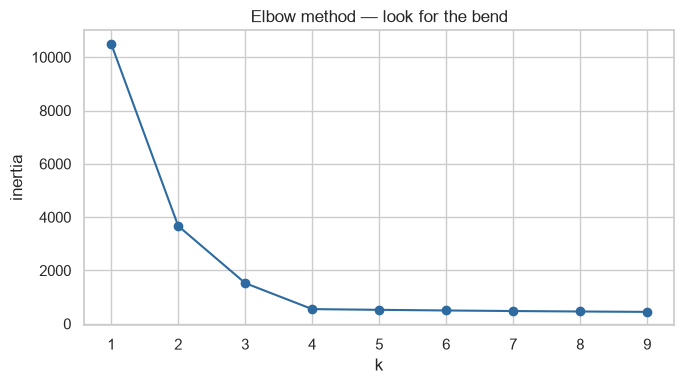

In [44]:
# -----------------------------------------------------------
# 🔹 3A. THE ELBOW METHOD (inertia vs k)
# -----------------------------------------------------------
ks = range(1, 10); inertias = []
for k in ks:
    inertias.append(KMeans(n_clusters=k, n_init=10, random_state=0).fit(Xs).inertia_)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(ks), inertias, 'o-', color='#2D6A9F')
ax.set_xlabel('k'); ax.set_ylabel('inertia'); ax.set_title('Elbow method — look for the bend')
plt.tight_layout(); plt.show()

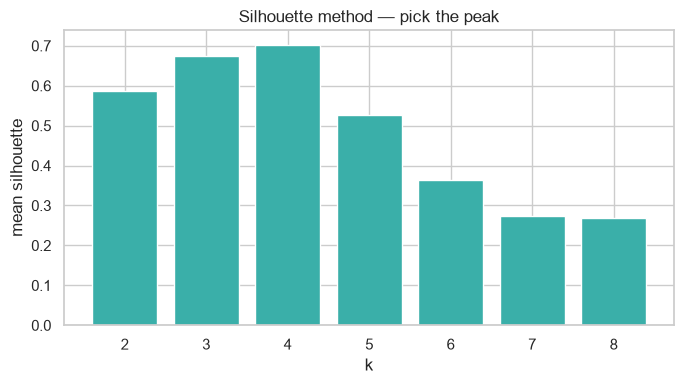

highest silhouette at k = 4


In [45]:
# -----------------------------------------------------------
# 🔹 3B. THE SILHOUETTE METHOD (higher = better separated)
# -----------------------------------------------------------
from sklearn.metrics import silhouette_score
ks2 = range(2, 9); sils = []
for k in ks2:
    labels = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(Xs)
    sils.append(silhouette_score(Xs, labels))
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([str(k) for k in ks2], sils, color='#3AAFA9')
ax.set_xlabel('k'); ax.set_ylabel('mean silhouette'); ax.set_title('Silhouette method — pick the peak')
plt.tight_layout(); plt.show()
best_k = list(ks2)[int(np.argmax(sils))]
print('highest silhouette at k =', best_k)

#### 🧪 EXERCISE 2 — Agree on k
1. From the elbow plot, state where you see the bend.
2. From the silhouette plot, read off the best k (`best_k` is computed for you).
3. In a comment, say whether the two methods agree — and recall the brief mentioned roughly four operating regimes.

In [47]:
# 1-3. compare elbow vs silhouette, connect to the 4 expected regimes: ...   (comment)
#elbow vs silhouette: elbow shows a bend at k = 4, silhouette peaks at k = 4.
#read off best_k
best_k = 4
# two methods agree on k = 4 , four operating regimes are expected, so k=4 is a good choice.




#4. Validate the clusters

In [25]:
# -----------------------------------------------------------
# 🔹 4A. INTERNAL METRICS AT THE CHOSEN k
# -----------------------------------------------------------
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
labels = KMeans(n_clusters=best_k, n_init=10, random_state=0).fit_predict(Xs)
print(f'k = {best_k}')
print('Silhouette       (higher better):', round(silhouette_score(Xs, labels), 3))
print('Davies-Bouldin   (lower  better):', round(davies_bouldin_score(Xs, labels), 3))
print('Calinski-Harabasz(higher better):', round(calinski_harabasz_score(Xs, labels), 1))

k = 4
Silhouette       (higher better): 0.703
Davies-Bouldin   (lower  better): 0.439
Calinski-Harabasz(higher better): 9022.9


#### 🧪 EXERCISE 3 — Compare two values of k
1. Compute all three metrics for `k = best_k` and for `k = best_k + 1`.
2. In a comment, state which k the metrics prefer and why no single metric is the final word (geometry ≠ business usefulness).

In [ ]:
# 1. metrics for best_k vs best_k+1
# YOUR CODE HERE
best_k_plus_1 = best_k + 1
labels_plus_1 = KMeans(n_clusters=best_k_plus_1, n_init=10, random_state=0).fit_predict(Xs)
print(f'k = {best_k_plus_1}')
print('Silhouette       (higher better):', round(silhouette_score(Xs, labels_plus_1), 3))
print('Davies-Bouldin   (lower  better):', round(davies_bouldin_score(Xs, labels_plus_1), 3))
print('Calinski-Harabasz(higher better):', round(calinski_harabasz_score(Xs, labels_plus_1), 1))



# 2. which k & why judgement still matters: ...   (comment)
#judgment still matters because the metrics may not always agree, and domain knowledge can help interpret the results. For example, even if the silhouette score is higher for k=5, if we know there are only 4 operating regimes, we might still choose k=4.


k = 5
Silhouette       (higher better): 0.527
Davies-Bouldin   (lower  better): 1.181
Calinski-Harabasz(higher better): 7138.8


#5. Profile & name the regimes

In [27]:
# -----------------------------------------------------------
# 🔹 5A. CLUSTER PROFILES = MEAN OF EACH FEATURE PER CLUSTER
# -----------------------------------------------------------
df_lab = df.copy()
df_lab['cluster'] = KMeans(n_clusters=best_k, n_init=10, random_state=0).fit_predict(Xs)
profile = df_lab.groupby('cluster').mean().round(1)
print(profile.to_string())
print('\nRead each row as the typical machine state for that cluster.')

         spindle_rpm  feed_rate_mmpm  cut_depth_mm  power_kw  vibration_mm_s  coolant_lpm  tool_temp_c
cluster                                                                                               
0             1496.2           399.6           3.5      18.0             5.5         25.0         61.9
1              699.1            19.7           0.2       1.8             0.6          2.3         28.0
2             2993.8           177.7           0.6       8.9             2.2         18.0         47.9
3             1096.3           600.7           6.0      25.8             8.5         30.1         77.8

Read each row as the typical machine state for that cluster.


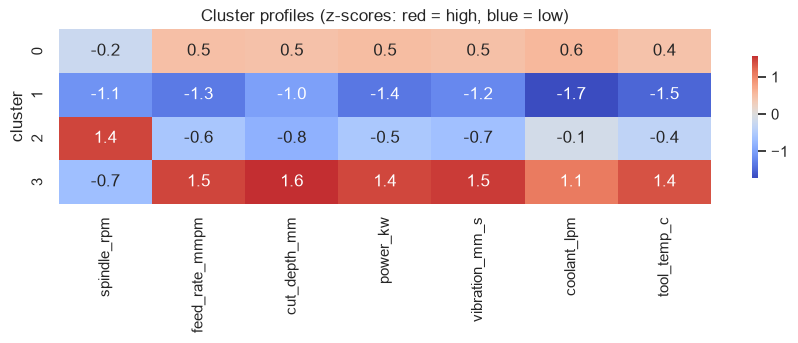

In [28]:
# -----------------------------------------------------------
# 🔹 5B. HEATMAP OF PROFILES (standardised for readability)
# -----------------------------------------------------------
prof_z = (profile - df.mean()) / df.std()
fig, ax = plt.subplots(figsize=(9, 3.6))
sns.heatmap(prof_z, annot=True, fmt='.1f', cmap='coolwarm', center=0, cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title('Cluster profiles (z-scores: red = high, blue = low)'); plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 4 — Name the clusters
Using the profile table/heatmap, give each cluster a plain-English regime name.
1. Match clusters to the suspected regimes — e.g. **idle** (low rpm, ~0 cut depth, low power), **roughing** (high feed & depth, high power), **finishing** (high rpm, low depth), **heavy cut** (highest power & vibration).
2. In a comment, write your cluster→regime mapping and one maintenance or scheduling action it enables.

In [29]:
# 1-2. cluster -> regime names + one action: ...   (comment)

#### 🧪 EXERCISE 5 — Preview: when k-means isn't enough
1. Run `DBSCAN(eps=1.0, min_samples=10)` on `Xs` and print the number of clusters found (`labels == -1` are noise points).
2. In a comment, note how DBSCAN differs from k-means (no preset k; it can label noise/outliers) and when you'd reach for it (odd-shaped clusters, unknown k).

In [30]:
from sklearn.cluster import DBSCAN
# 1. DBSCAN on Xs; count clusters and noise points
# YOUR CODE HERE

# 2. DBSCAN vs k-means: ...   (comment)

#📘 Summary

| Step | Tool | Lesson |
| ---- | ---- | ------ |
| Scale | StandardScaler | every feature gets an equal vote |
| Cluster | KMeans (n_init=10) | minimise within-cluster inertia |
| Choose k | elbow + silhouette | the bend and the peak should roughly agree |
| Validate | silhouette, Davies-Bouldin, CH | score geometry without labels |
| Profile | groupby().mean() | turn clusters into named regimes + actions |

**Core lesson:** k-means recovers hidden structure — but only after scaling, with k chosen deliberately, and clusters profiled into something the plant can actually use.

**Next — U19:** Clustering Part 2 — hierarchical clustering, DBSCAN and Gaussian mixtures in depth.